In [5]:
import seaborn as sns
from TFG_Chollos.utils import conseguir_ruta_general_TFG
import pandas as pd

BASE = conseguir_ruta_general_TFG()

df = pd.read_parquet(BASE / 'data' / 'processed' / 'final' / 'db_final.parquet')

In [ ]:
#Observamos que los tipos de datos sean correctos y los valores únicos de cada columna:

df.info()

print("="*50)
print(f'Analizamos la base de Datos:')
print("="*50)

for col in df.columns:
    print(col, df[col].unique(), '\n')

<class 'pandas.DataFrame'>
RangeIndex: 3123524 entries, 0 to 3123523
Data columns (total 33 columns):
 #   Column               Dtype         
---  ------               -----         
 0   provincia            str           
 1   localidad            str           
 2   titulo               str           
 3   codigo_postal        int32         
 4   latitud              float64       
 5   longitud             float64       
 6   distancia_centro_km  float32       
 7   latitud_centro       float64       
 8   longitud_centro      float64       
 9   tipo                 category      
 10  estrellas            int8          
 11  valoracion_clientes  float32       
 12  n_valoraciones       int64         
 13  url_estancia         str           
 14  Parking              int8          
 15  Parking_gratis       int8          
 16  Gimnasio             int8          
 17  Restaurante          int8          
 18  Piscina              int8          
 19  Piscina_interior     int8       

Hacer un boxplot de todas las variables para eliminar outliers:

### Precio

<Axes: ylabel='precio'>

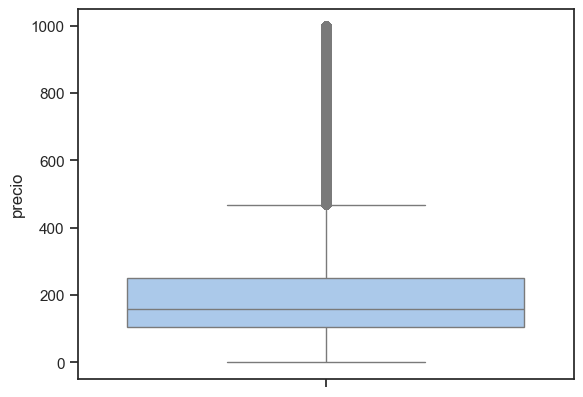

In [4]:
sns.set_theme(style="ticks", palette="pastel")

sns.boxplot(y='precio', data=df)

Como vemos, hay una densidad considerable de outliers (valores anormales, no errores en este caso). Según Tukey (boxplot), los valores 'anormales' son los que están fuera de este umbral [Q1 - 1.5·IQR, Q3 + 1.5·IQR], donde IQR = Q3 - Q1, es decir, en nuestro caso, si está por arriba de 1.5 veces la diferencia entre cuantiles, es un outlier.
         o      ← 468.5€  punto outlier (fuera)

        468€    ← bigote superior real (último valor dentro del límite)                
         |
    _____|____
    |        |
    | Q3=251€|
    |--------|  ← mediana = 100€
    | Q1=106€|
    |________|
         | 
         | 
        20€   ← bigote inferior real (primer valor dentro del límite)

         o    ← 19.5€  punto outlier (posible chollo)

Tukey fue diseñado para detectar anomalías estadísticas, no anomalías de
negocio. Un hotel a 500€/noche puede ser perfectamente real (un 5 estrellas en Semana Santa), pero estadísticamente es un outlier porque la mayoría de tus datos son precios más bajos.

Dado que el objetivo del proyecto es predecir chollos (ofertas con muchos servicios a un precio anormalmente bajo), los registros de +500€/noche difícilmente van a ser chollos, y además distorsionarían el modelo al introducir una escala de precios muy diferente a la del rango útil. 

### Tamaño de la Habitación

In [3]:
sns.boxplot(x='tipo', y='tamaño_habitacion', data=df)

NameError: name 'sns' is not defined

¿De qué se tratan los valores > 2000 en 'tamaño_habitacion'?
Lo comprobamos

In [ ]:
mas2000 =  df[df['tamaño_habitacion'] > 2000]
pd.set_option('display.max_colwidth', None)
print(mas2000[['url_estancia', 'tamaño_habitacion']].drop_duplicates(subset='url_estancia'))

                                                                                                                                                                                                                              url_estancia  \
86829    https://www.booking.com/hotel/es/la-casa-del-valle-descansar-junto-a-donana-en-plena-naturaleza-manzanilla1.es.html?checkin=2026-09-16&checkout=2026-09-19&group_adults=2&req_adults=2&no_rooms=1&group_children=0&req_children=0   
98714                                             https://www.booking.com/hotel/es/finca-contrabando-completa-20-pax.es.html?checkin=2026-09-16&checkout=2026-09-19&group_adults=2&req_adults=2&no_rooms=1&group_children=0&req_children=0   
411220                                                     https://www.booking.com/hotel/es/los-candiles-cantillana2.es.html?checkin=2026-09-16&checkout=2026-09-19&group_adults=2&req_adults=2&no_rooms=1&group_children=0&req_children=0   
958081                                          

Los alojamientos con valores mayores a 2000, son fincas, casas rurales, villas... Estas son categorías que se deberían analizar aparte, dado a su gran diversidad de tipos y de valores elevado. 
Tenemos 2 opciones para gestionar este problema:
- Fijar un umbral mayor al umbral de Tukey para eliminar muchos o todos de estos tipos de alojamiento, que perjudicarían la modelización
- Trabajamos solo con los hoteles que tenemos en la base de datos

In [23]:
n_registros_hoteles = len(df[df['tipo']=='Hotel'])
n_registros_otros = len(df[df['tipo']=='Otro'])
print((n_registros_hoteles/len(df)) * 100)
print((n_registros_otros/len(df))*100)

7.932322594607885
92.06767740539212


Dado a que los hoteles en la base de datos representan alrededor del 8%, fijamos un umbral de 500m²

In [26]:
print(f'Registros eliminados por tamaño_habitacion > 500m²: {len(df) - len(df[df['tamaño_habitacion'] <= 500])} registros')

Registros eliminados por tamaño_habitacion > 500m²: 23004 registros


In [10]:
import seaborn as sns
from TFG_Chollos.utils import conseguir_ruta_general_TFG
import pandas as pd

BASE = conseguir_ruta_general_TFG()

df_codificado = pd.read_parquet(BASE / 'data' / 'processed' / 'modelizacion' / 'db_final_codificada.parquet')
df_codificado[df_codificado['tamaño_habitacion']>500]

,provincia,localidad,latitud,longitud,distancia_centro_km,latitud_centro,longitud_centro,estrellas,valoracion_clientes,n_valoraciones,...,Terraza,Baño_privado,tamaño_habitacion,dias_restantes,es_finde,es_domingo,precio,tipo_Otro,mes_disponible,dia_disponible


KeyboardInterrupt: 

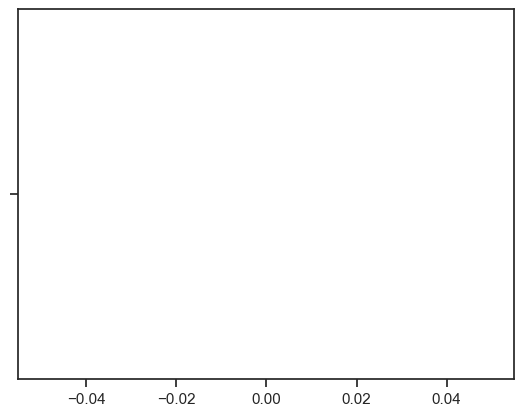

In [ ]:
# sns.barplot(x='estrellas', data=df)